In [2]:
# Step 1 — Import essential libraries

import pandas as pd       # for handling datasets (tables)
import numpy as np        # for numerical operations
import matplotlib.pyplot as plt   # for visualizations
import seaborn as sns     # for nicer statistical plots

# Make plots look better
plt.style.use('seaborn-v0_8')
sns.set_palette('viridis')

print("✅ Libraries imported successfully!")


✅ Libraries imported successfully!


In [2]:
import pandas as pd  

datasets = {
    "hallways1": pd.read_csv("hallways-generated-2542-p2-o4-box-sd010n005-0.csv", skiprows=2, sep=",", low_memory=False),
    "hallways2": pd.read_csv("hallways-generated-2542-p2-o4-box-sd010n005-1.csv", skiprows=2, sep=",", low_memory=False),
    "hallways3": pd.read_csv("hallways-generated-2542-p2-o4-box-sd010n005-2.csv", skiprows=2, sep=",", low_memory=False),
}

print("✅ All datasets loaded successfully without warnings!")


✅ All datasets loaded successfully without warnings!


In [3]:
# --- Load & Combine Datasets ---
dfs = []
for run_name in ["hallways1", "hallways2", "hallways3"]:   
    temp_df = datasets[run_name].copy()
    temp_df["run_id"] = run_name                           # Add run identifier
    dfs.append(temp_df)

In [4]:
# Combine all runs into one DataFrame
df = pd.concat(dfs, ignore_index=True)

In [5]:
# Inspect dataset structure
print("=== Dataset Info ===")
print(df.info())
print("\n=== Column Names ===")
print(df.columns.tolist())

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235 entries, 0 to 234
Columns: 346 entries, timestamp to run_id
dtypes: float64(281), int64(1), object(64)
memory usage: 635.4+ KB
None

=== Column Names ===
['timestamp', 'topic', 'type', 'header.stamp.sec', 'header.stamp.nanosec', 'header.frame_id', 'pose.pose.position.x', 'pose.pose.position.y', 'pose.pose.position.z', 'pose.pose.orientation.x', 'pose.pose.orientation.y', 'pose.pose.orientation.z', 'pose.pose.orientation.w', 'pose.covariance', 'transforms[0].header.stamp.sec', 'transforms[0].header.stamp.nanosec', 'transforms[0].header.frame_id', 'transforms[0].child_frame_id', 'transforms[0].transform.translation.x', 'transforms[0].transform.translation.y', 'transforms[0].transform.translation.z', 'transforms[0].transform.rotation.x', 'transforms[0].transform.rotation.y', 'transforms[0].transform.rotation.z', 'transforms[0].transform.rotation.w', 'transforms[1].header.stamp.sec', 'transforms[1].header.stamp.nano

In [6]:
# Basic statistical overview
print("\n=== Statistical Summary (Numeric Columns) ===")
print(df.describe().T)


=== Statistical Summary (Numeric Columns) ===
                      count          mean           std           min  \
timestamp             235.0  3.378498e+09  1.734623e+08  3.027000e+09   
header.stamp.sec        3.0  0.000000e+00  0.000000e+00  0.000000e+00   
header.stamp.nanosec    3.0  1.020000e+08  0.000000e+00  1.020000e+08   
pose.pose.position.x    3.0  4.008009e+00  0.000000e+00  4.008009e+00   
pose.pose.position.y    3.0  4.777932e+00  0.000000e+00  4.777932e+00   
...                     ...           ...           ...           ...   
orientation.w          59.0  9.582678e-01  0.000000e+00  9.582678e-01   
system_time.sec        31.0  1.758725e+09  1.327486e+04  1.758705e+09   
system_time.nanosec    31.0  5.323929e+08  2.195903e+08  7.715732e+07   
ros_time.sec           31.0  3.000000e+00  0.000000e+00  3.000000e+00   
ros_time.nanosec       31.0  4.558065e+08  2.021756e+08  1.020000e+08   

                               25%           50%           75%           max

In [7]:
# --- Select Important Columns ---
important_cols = [
    'timestamp',
    'pose.pose.position.x', 'pose.pose.position.y',
    'position.x', 'position.y',
    'data', 'run_id'
]

In [8]:
df_subset = df[important_cols].copy()

In [9]:
# --- Missing Value Check Before Cleaning ---
print("Missing values before cleaning:")
print(df_subset[['pose.pose.position.x', 'pose.pose.position.y', 'position.x', 'position.y', 'data']].isna().sum())


Missing values before cleaning:
pose.pose.position.x    232
pose.pose.position.y    232
position.x              176
position.y              176
data                    190
dtype: int64


In [10]:
# --- Drop Rows with All NaN Position Values ---
df_subset = df_subset.dropna(subset=[
    'position.x', 'position.y',
    'pose.pose.position.x', 'pose.pose.position.y'
], how='all')

In [11]:
# --- Missing Value Check After Cleaning ---
print("\nMissing values after cleaning:")
print(df_subset[['pose.pose.position.x', 'pose.pose.position.y', 'position.x', 'position.y', 'data']].isna().sum())



Missing values after cleaning:
pose.pose.position.x    59
pose.pose.position.y    59
position.x               3
position.y               3
data                    62
dtype: int64


In [51]:
df_subset.head(100)

,timestamp,pose.pose.position.x,pose.pose.position.y,position.x,position.y,data,run_id
0,3027000000,4.008009,4.777932,NaN,NaN,NaN,hallways1
7,3060000000,NaN,NaN,4.008025,4.777943,NaN,hallways1
9,3078000000,NaN,NaN,4.008025,4.777943,NaN,hallways1
12,3096000000,NaN,NaN,4.008025,4.777943,NaN,hallways1
17,3105000000,NaN,NaN,4.008025,4.777943,NaN,hallways1
...,...,...,...,...,...,...,...
214,3525000000,NaN,NaN,4.008025,4.777943,NaN,hallways3
217,3543000000,NaN,NaN,4.008025,4.777943,NaN,hallways3
219,3561000000,NaN,NaN,4.008025,4.777943,NaN,hallways3
223,3579000000,NaN,NaN,4.008025,4.777943,NaN,hallways3


In [13]:
# --- Trajectory Plot for Each Run ---
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))


<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

In [14]:
colors = {
    "hallways1": "blue",
    "hallways2": "green",
    "hallways3": "red"
}

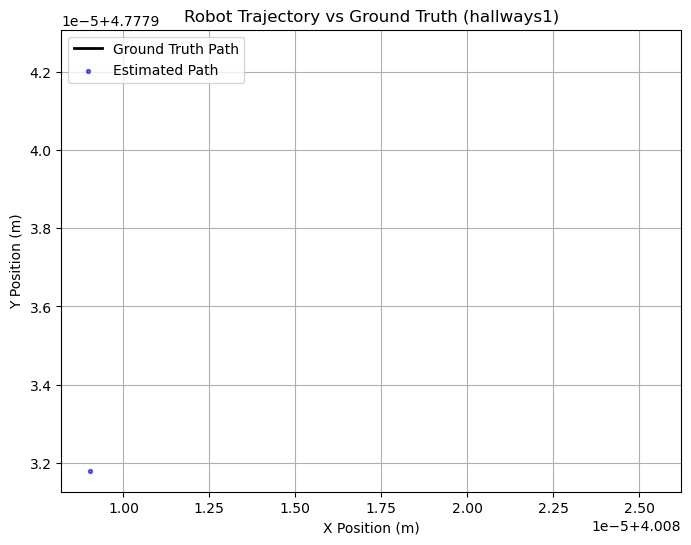

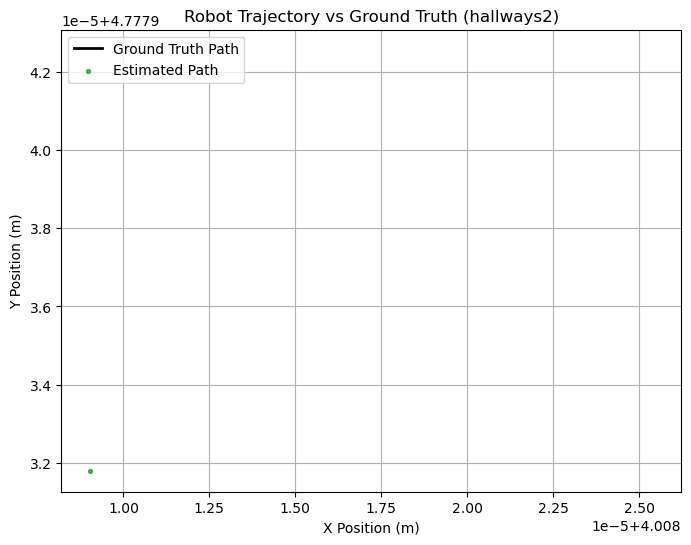

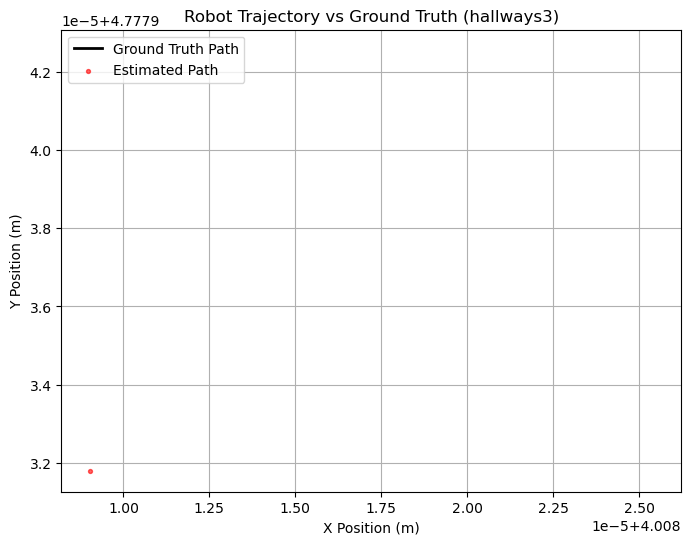

In [15]:
# --- Separate Trajectory Plots for Each Run ---
for run_name, color in colors.items():
    run_data = df_subset[df_subset["run_id"] == run_name]

    plt.figure(figsize=(8, 6))
    plt.plot(run_data['position.x'], run_data['position.y'],
             color='black', linewidth=2, label='Ground Truth Path')
    plt.scatter(run_data['pose.pose.position.x'], run_data['pose.pose.position.y'],
                color=color, s=8, alpha=0.6, label='Estimated Path')

    plt.title(f"Robot Trajectory vs Ground Truth ({run_name})")
    plt.xlabel("X Position (m)")
    plt.ylabel("Y Position (m)")
    plt.legend()
    plt.grid(True)
    plt.show()


In [ ]:
Scenario Description

Start Pose: (x = 4.0080, y = 4.7779, yaw = 0.5798)

Goal Pose: (x = 5.2891, y = -5.0146, yaw = 1.3863)

The YAML file specifies a navigation task where the robot should move from the top-right of the hallway map toward the lower area, avoiding several static obstacles.

Observation from Logged Data

The pose.pose.position.x and pose.pose.position.y values remain nearly constant across all timestamps.

These position values are almost identical to the defined start pose in the YAML file.

The same pattern is seen for all three runs (hallways1, hallways2, hallways3).

Interpretation

The robot did not exhibit any actual movement during the logged runs.

Possible reasons:

The robot failed to start navigation or got stuck at initialization.

The logging process only recorded static transforms (e.g., map→odom) and missed dynamic ones (odom→base_link).

Conclusion

The data for the hallways scenario shows no motion, suggesting a simulation or logging issue.

For meaningful motion analysis or performance evaluation, these runs should either be:

excluded as failed simulations, or

investigated further to verify the recorded topics.

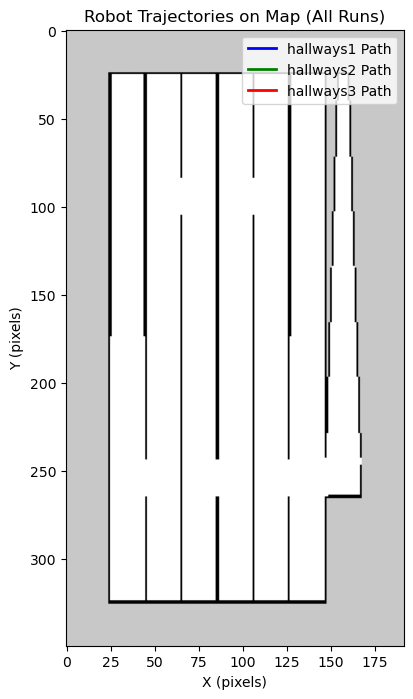

In [18]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import yaml
# --- Map-Based Visualization for All Runs ---
with open("hallways.yaml", 'r') as f:
    map_info = yaml.safe_load(f)

resolution = map_info['resolution']      # e.g., 0.05
origin = map_info['origin'][:2]          # e.g., [-1.77, -1.49]
map_image = mpimg.imread("hallways.pgm")

plt.figure(figsize=(8, 8))
plt.imshow(map_image, cmap='gray')

for run_name, color in colors.items():
    run_data = df_subset[df_subset["run_id"] == run_name]
    x_pixels = (run_data['position.x'] - origin[0]) / resolution
    y_pixels = (run_data['position.y'] - origin[1]) / resolution
    y_pixels_flipped = map_image.shape[0] - y_pixels
    plt.plot(x_pixels, y_pixels_flipped, color=color, linewidth=2, label=f"{run_name} Path")

plt.title("Robot Trajectories on Map (All Runs)")
plt.xlabel("X (pixels)")
plt.ylabel("Y (pixels)")
plt.legend()
plt.show()

In [ ]:
start_pose:
  position:
    x: 4.008009015415047
    y: 4.777931803065092

goal_poses:
  - position:
      x: 5.289100174604297
      y: -5.01465604465875


In [52]:
# Convert world to pixel coordinates
def to_pixel(x, y, resolution, origin, map_image):
    x_pix = (x - origin[0]) / resolution
    y_pix = map_image.shape[0] - ((y - origin[1]) / resolution)
    return x_pix, y_pix

# Hallways scenario start and goal
start_px = to_pixel(4.008009015415047, 4.777931803065092, resolution, origin, map_image)
goal_px = to_pixel(5.289100174604297, -5.01465604465875, resolution, origin, map_image)

print("Start (pixels):", start_px)
print("Goal (pixels):", goal_px)


Start (pixels): (115.16018030830094, 79.44136393869815)
Goal (pixels): (140.78200349208592, 275.293120893175)


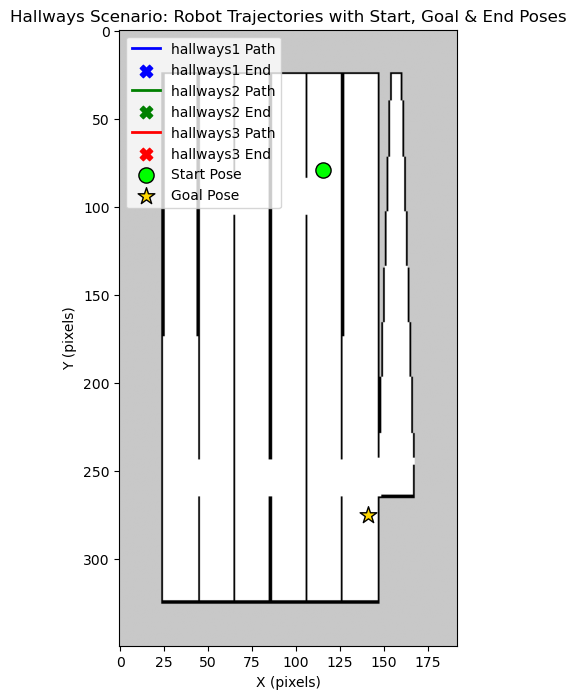

Distance from final pose to goal (in meters):
hallways1: 9.876 m
hallways2: 9.876 m
hallways3: 9.876 m


In [53]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import yaml
import numpy as np

# --- Load map info ---
with open("hallways.yaml", 'r') as f:
    map_info = yaml.safe_load(f)

resolution = map_info['resolution']
origin = map_info['origin'][:2]
map_image = mpimg.imread("hallways.pgm")

# --- Helper function: world → pixel ---
def to_pixel(x, y, resolution, origin, map_image):
    x_pix = (x - origin[0]) / resolution
    y_pix = map_image.shape[0] - ((y - origin[1]) / resolution)
    return x_pix, y_pix

# --- Start & Goal (from hallways scenario) ---
start_world = (4.008009015415047, 4.777931803065092)
goal_world = (5.289100174604297, -5.01465604465875)

start_px = to_pixel(*start_world, resolution, origin, map_image)
goal_px = to_pixel(*goal_world, resolution, origin, map_image)

# --- Plot map and trajectories ---
plt.figure(figsize=(8, 8))
plt.imshow(map_image, cmap='gray')

# Example color dictionary (for 3 runs)
colors = {
    "hallways1": "blue",
    "hallways2": "green",
    "hallways3": "red"
}

# --- Plot each run ---
distances_to_goal = {}
for run_name, color in colors.items():
    run_data = df_subset[df_subset["run_id"] == run_name]

    # Plot trajectory path
    x_pixels = (run_data['position.x'] - origin[0]) / resolution
    y_pixels = map_image.shape[0] - ((run_data['position.y'] - origin[1]) / resolution)
    plt.plot(x_pixels, y_pixels, color=color, linewidth=2, label=f"{run_name} Path")

    # Final pose
    final_x = run_data['position.x'].iloc[-1]
    final_y = run_data['position.y'].iloc[-1]

    # Convert to pixels
    final_px = to_pixel(final_x, final_y, resolution, origin, map_image)
    plt.scatter(final_px[0], final_px[1], color=color, marker='X', s=80, label=f"{run_name} End")

    # Compute distance from goal (in meters)
    dist_to_goal = np.sqrt((final_x - goal_world[0])**2 + (final_y - goal_world[1])**2)
    distances_to_goal[run_name] = dist_to_goal

# --- Plot start & goal markers ---
plt.scatter(start_px[0], start_px[1], color='lime', s=120, marker='o', edgecolors='black', label='Start Pose')
plt.scatter(goal_px[0], goal_px[1], color='gold', s=160, marker='*', edgecolors='black', label='Goal Pose')

# --- Add labels & legend ---
plt.title("Hallways Scenario: Robot Trajectories with Start, Goal & End Poses")
plt.xlabel("X (pixels)")
plt.ylabel("Y (pixels)")
plt.legend()
plt.grid(False)
plt.show()

# --- Print distance summary ---
print("Distance from final pose to goal (in meters):")
for run_name, dist in distances_to_goal.items():
    print(f"{run_name}: {dist:.3f} m")


In [ ]:
Interpretation: Robot Stuck / No Navigation Occurred
🔍 What the Plot Shows

The green circle (Start Pose) and the colored “paths” (for hallways1, hallways2, hallways3) are all clustered together in one location.

The goal (yellow star) is far away — at the bottom right of the hallway map.

The path lines are essentially just single points or extremely short traces, not continuous movement.

👉 That means the robot did not actually traverse the map.

In [56]:
# Check if position.x or y changes over time
df[['pose.pose.position.x', 'pose.pose.position.y']]#.describe()

# Or quickly visualize the change
#df[['pose.pose.position.x', 'pose.pose.position.y']].plot()


,pose.pose.position.x,pose.pose.position.y
0,4.008009,4.777932
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN
...,...,...
230,NaN,NaN
231,NaN,NaN
232,NaN,NaN
233,NaN,NaN


In [ ]:
In the Hallways scenario, the plotted trajectories reveal no observable robot movement from the start pose toward the goal.
This indicates that navigation did not occur, likely due to localization or planner initialization failure or incomplete logging.
As a result, no navigation performance metrics (path length, accuracy, convergence) can be derived for this run.

C:\Users\keert\AppData\Local\Temp\ipykernel_15188\3633111394.py:5: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df_subset['pose.pose.position.x'], label='Estimated X', fill=True)


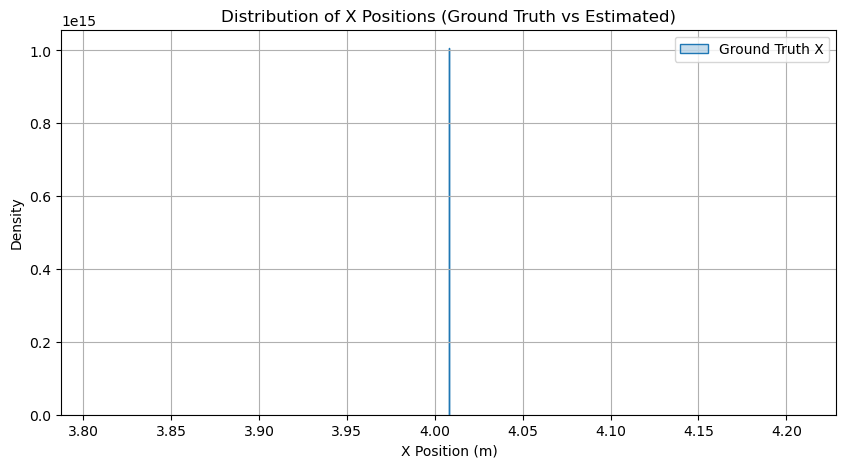

In [20]:
# --- Quick Visualization: Pose Distributions ---
import seaborn as sns 
plt.figure(figsize=(10, 5))
sns.kdeplot(df_subset['position.x'], label='Ground Truth X', fill=True)
sns.kdeplot(df_subset['pose.pose.position.x'], label='Estimated X', fill=True)
plt.title("Distribution of X Positions (Ground Truth vs Estimated)")
plt.xlabel("X Position (m)")
plt.legend()
plt.grid(True)
plt.show()

C:\Users\keert\AppData\Local\Temp\ipykernel_15188\15900226.py:3: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(df_subset['pose.pose.position.y'], label='Estimated Y', fill=True)


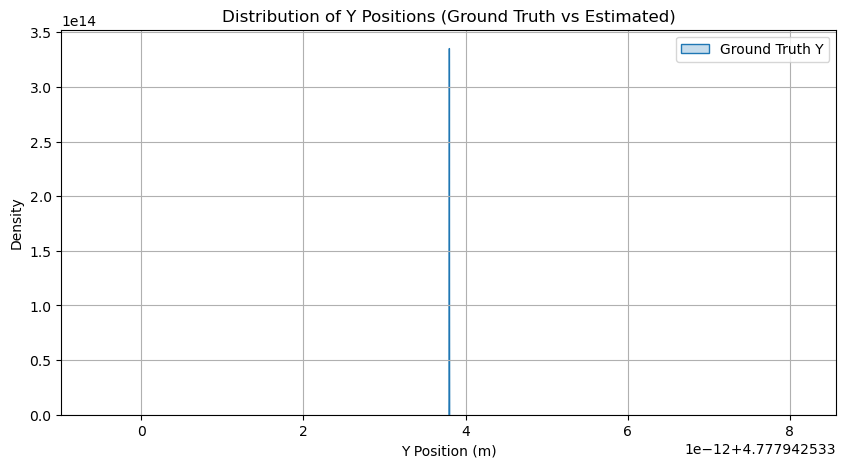

In [22]:
plt.figure(figsize=(10, 5))
sns.kdeplot(df_subset['position.y'], label='Ground Truth Y', fill=True)
sns.kdeplot(df_subset['pose.pose.position.y'], label='Estimated Y', fill=True)
plt.title("Distribution of Y Positions (Ground Truth vs Estimated)")
plt.xlabel("Y Position (m)")
plt.legend()
plt.grid(True)
plt.show()


In [49]:
df[[c for c in df.columns if 'header.frame_id' in c]].head(1).T


,0
header.frame_id,map
transforms[0].header.frame_id,NaN
transforms[1].header.frame_id,NaN
transforms[2].header.frame_id,NaN
transforms[3].header.frame_id,NaN
transforms[4].header.frame_id,NaN
transforms[5].header.frame_id,NaN
transforms[6].header.frame_id,NaN
transforms[7].header.frame_id,NaN
transforms[8].header.frame_id,NaN


In [26]:
# --- Select Important Columns (timestamp + transform) ---
important_cols = [
    'timestamp','header.stamp.sec', 'header.stamp.nanosec', 'header.frame_id',
    'run_id','transforms[0].header.stamp.sec', 'transforms[0].header.stamp.nanosec',
    'transforms[0].transform.translation.x',
    'transforms[0].transform.translation.y',
    'transforms[0].transform.translation.z',
    'transforms[0].child_frame_id'
]


In [27]:
# --- Create Subset ---
df_subset1 = df[important_cols].copy()


In [28]:

# --- Missing Value Check Before Cleaning ---
print("Missing values before cleaning:")
print(df_subset1[['transforms[0].transform.translation.x',
                  'transforms[0].transform.translation.y',
                  'transforms[0].transform.translation.z']].isna().sum())



Missing values before cleaning:
transforms[0].transform.translation.x    107
transforms[0].transform.translation.y    107
transforms[0].transform.translation.z    107
dtype: int64


In [29]:
# --- Drop Rows with All NaN Transform Values ---
df_subset1 = df_subset1.dropna(subset=[
    'transforms[0].transform.translation.x',
    'transforms[0].transform.translation.y',
    'transforms[0].transform.translation.z'
], how='all')


In [30]:
# --- Missing Value Check After Cleaning ---
print("\nMissing values after cleaning:")
print(df_subset1[['transforms[0].transform.translation.x',
                  'transforms[0].transform.translation.y',
                  'transforms[0].transform.translation.z']].isna().sum())



Missing values after cleaning:
transforms[0].transform.translation.x    0
transforms[0].transform.translation.y    0
transforms[0].transform.translation.z    0
dtype: int64
